# Exploratory Data Analysis & Visualization

This notebook performs exploratory data analysis on a cleaned customer sales dataset.

The analysis builds on the data-cleaning work completed previously and uses Matplotlib to visualize transaction distributions, category-level sales, and relationships between numerical variables.

Each visualization is paired with an analytical question and a written finding so that the charts support clear conclusions.

## Introduction

Exploratory Data Analysis (EDA) combines numerical analysis and visualization to understand the structure and patterns within a dataset.

The dataset used in this notebook represents customer sales transactions. Before visualization, missing values and inconsistent category names are handled using the cleaning strategy established in the previous exercise.

The analysis then uses different visualization types according to the analytical question:

- Histograms for distributions.
- Bar charts for category comparisons.
- Scatter plots for relationships between numerical variables.
- Subplots for comparing multiple views together.

The notebook also demonstrates how visualization choices can create misleading impressions even when the underlying data is correct.

## 1. Setup and Imports

The analysis uses Pandas for tabular data manipulation, NumPy for numerical operations, and Matplotlib for data visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Recreating the Raw Sales Dataset

The previous exercise used a deliberately messy customer sales dataset containing missing values and inconsistent category capitalization.

Because this notebook starts with a fresh kernel, the dataset and its cleaning steps are reproduced here so that the analysis is self-contained and reproducible.

In [2]:
sales_data = {
    "date": [
        "2026-08-01",
        "2026-08-02",
        "2026-08-03",
        "2026-08-04",
        "2026-08-05",
        "2026-08-06",
        "2026-08-07",
        "2026-08-08",
        "2026-08-09",
        "2026-08-10",
    ],
    "category": [
        "Electronics",
        "Clothing",
        "electronics",
        None,
        "Furniture",
        "Clothing",
        "Electronics",
        "Furniture",
        "electronics",
        "Clothing",
    ],
    "amount": [
        1200,
        450,
        None,
        800,
        300,
        None,
        1500,
        650,
        900,
        550,
    ],
    "customer_age": [
        25,
        31,
        28,
        None,
        42,
        35,
        None,
        29,
        24,
        38,
    ],
}

df = pd.DataFrame(sales_data)

df

,date,category,amount,customer_age
0,2026-08-01,Electronics,1200.0,25.0
1,2026-08-02,Clothing,450.0,31.0
2,2026-08-03,electronics,NaN,28.0
3,2026-08-04,NaN,800.0,NaN
4,2026-08-05,Furniture,300.0,42.0
5,2026-08-06,Clothing,NaN,35.0
6,2026-08-07,Electronics,1500.0,NaN
7,2026-08-08,Furniture,650.0,29.0
8,2026-08-09,electronics,900.0,24.0
9,2026-08-10,Clothing,550.0,38.0


### Applying the Previous Cleaning Strategy

The dataset is cleaned using the same decisions established during the previous Pandas exercise.

The row with a missing category is removed, missing numerical values are filled using their respective medians, and category names are standardized to lowercase.

In [3]:
cleaned_df = df.copy()

cleaned_df = cleaned_df.dropna(subset=["category"])

amount_median = cleaned_df["amount"].median()
cleaned_df["amount"] = cleaned_df["amount"].fillna(amount_median)

age_median = cleaned_df["customer_age"].median()
cleaned_df["customer_age"] = cleaned_df["customer_age"].fillna(age_median)

cleaned_df["category"] = cleaned_df["category"].str.lower()

### Cleaning Verification

Before beginning the exploratory analysis, we verify that the dataset contains no missing values and that the category values have been standardized.

In [4]:
print("Missing values:")
print(cleaned_df.isna().sum())

print("\nUnique categories:")
print(cleaned_df["category"].unique())

print("\nDataset shape:")
print(cleaned_df.shape)
cleaned_df

Missing values:
date            0
category        0
amount          0
customer_age    0
dtype: int64

Unique categories:
<StringArray>
['electronics', 'clothing', 'furniture']
Length: 3, dtype: str

Dataset shape:
(9, 4)


,date,category,amount,customer_age
0,2026-08-01,electronics,1200.0,25.0
1,2026-08-02,clothing,450.0,31.0
2,2026-08-03,electronics,650.0,28.0
4,2026-08-05,furniture,300.0,42.0
5,2026-08-06,clothing,650.0,35.0
6,2026-08-07,electronics,1500.0,30.0
7,2026-08-08,furniture,650.0,29.0
8,2026-08-09,electronics,900.0,24.0
9,2026-08-10,clothing,550.0,38.0


## 2. Understanding Figure and Axes

Matplotlib separates a visualization into a Figure and one or more Axes.

The Figure represents the complete canvas that contains the visualization, while an Axes represents an individual plotting area where data is drawn.

Understanding this distinction is important when creating multiple plots or controlling individual plots explicitly.

Figure type: <class 'matplotlib.figure.Figure'>
Axes type: <class 'matplotlib.axes._axes.Axes'>


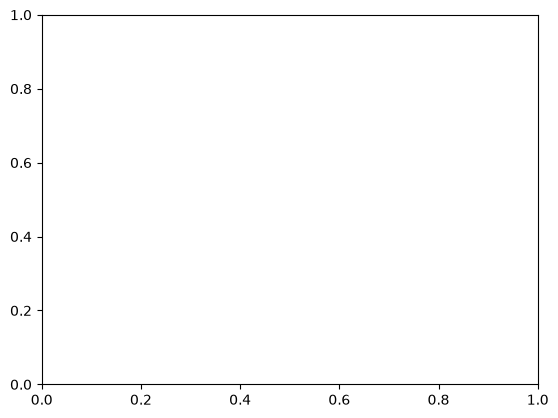

In [5]:
fig, ax = plt.subplots()

print("Figure type:", type(fig))
print("Axes type:", type(ax))

### Observing the Figure and Axes Objects

The `fig` object represents the complete Matplotlib Figure, while `ax` represents the individual Axes where plotting commands are applied.

The Figure can contain one or more Axes. A single Figure with one Axes is sufficient for a simple chart, while more complex visualizations can contain multiple Axes.

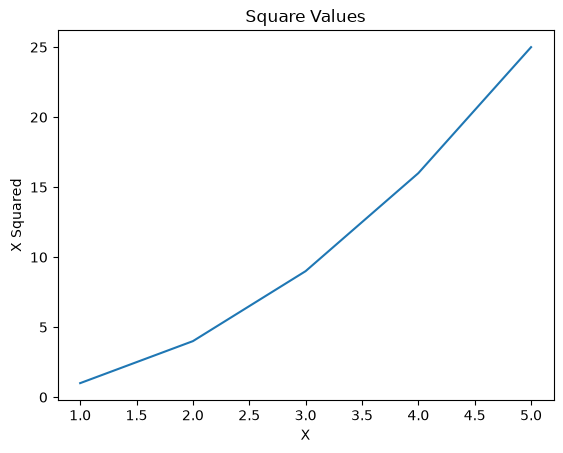

In [6]:
x = np.arange(1, 6)
y = x ** 2

fig, ax = plt.subplots()

ax.plot(x, y)

ax.set_title("Square Values")
ax.set_xlabel("X")
ax.set_ylabel("X Squared")

plt.show()

Number of Axes in Figure: 1
Axes object: Axes(0.125,0.11;0.775x0.77)


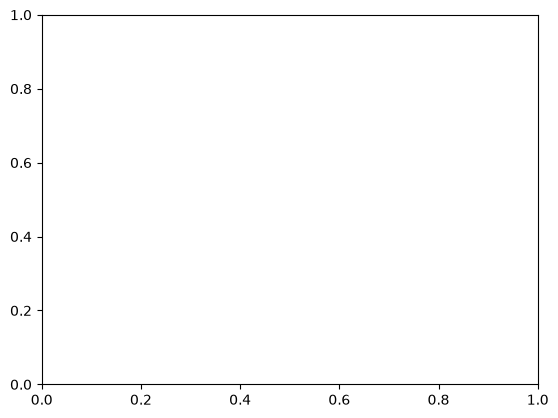

In [7]:

fig, ax = plt.subplots()

print("Number of Axes in Figure:", len(fig.axes))
print("Axes object:", fig.axes[0])

Number of Axes: 2
Axes shape: (2,)


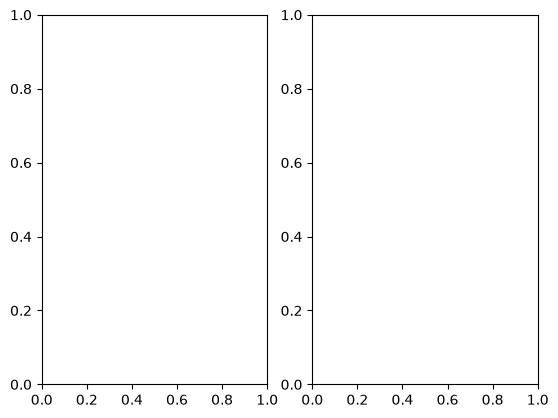

In [8]:
fig, axes = plt.subplots(1, 2)

print("Number of Axes:", len(fig.axes))
print("Axes shape:", axes.shape)

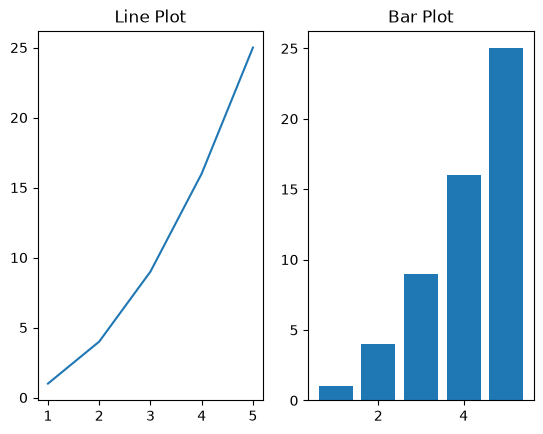

In [9]:
fig, axes = plt.subplots(1, 2)

axes[0].plot(x, y)
axes[0].set_title("Line Plot")

axes[1].bar(x, y)
axes[1].set_title("Bar Plot")

plt.show()

### Interpretation

The experiment demonstrates that a Matplotlib Figure acts as the overall container for one or more Axes. Each Axes represents an individual plotting area where data and labels are configured.

With a single plot, one Figure can contain one Axes. When multiple plots are required, the same Figure can contain multiple Axes, allowing the plots to be organized and compared within a single visualization.

## 3. One Chart Per Analytical Question

Visualization is used here to answer specific analytical questions rather than simply decorate the notebook.

For each question, we will select a chart type that matches the structure of the data, create the visualization using the Figure/Axes approach, and then write a finding based on the observed result.

### Question 1 — How Are Transaction Amounts Distributed?

A histogram is appropriate because we want to understand the distribution of a single numerical variable, `amount`.

The histogram can help reveal the concentration, spread, and potential skew of transaction amounts.

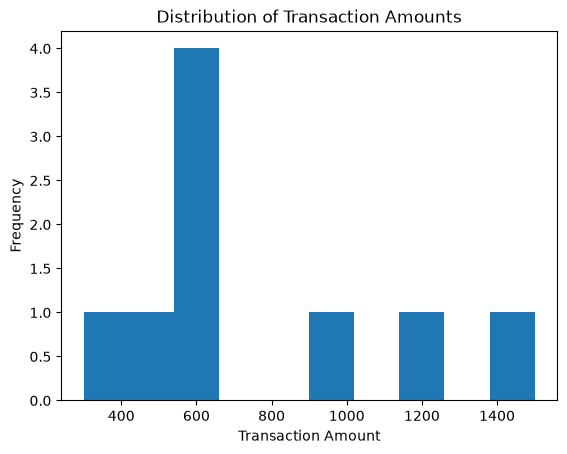

In [10]:
fig, ax = plt.subplots()

ax.hist(cleaned_df["amount"])

ax.set_title("Distribution of Transaction Amounts")
ax.set_xlabel("Transaction Amount")
ax.set_ylabel("Frequency")

plt.show()

### Finding

The histogram shows how the transaction amounts are distributed across the dataset. Most transaction amounts are concentrated within the observed range, while the larger transactions appear toward the upper end of the distribution.

Because this dataset contains only a small number of transactions, the histogram should be interpreted as a visual description of this sample rather than as evidence of a broader population distribution.

### Question 2 — Which Category Generated the Highest Total Amount?

A bar chart is appropriate because the goal is to compare a numerical aggregate across discrete categories.

We will calculate the total transaction amount for each category and visualize the results.

In [11]:
total_amount_by_category = (
    cleaned_df
    .groupby("category")["amount"]
    .sum()
)

total_amount_by_category

category
clothing       1650.0
electronics    4250.0
furniture       950.0
Name: amount, dtype: float64

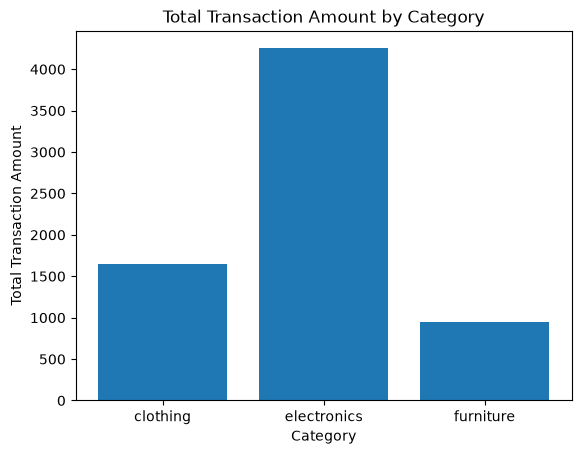

In [12]:
fig, ax = plt.subplots()

ax.bar(
    total_amount_by_category.index,
    total_amount_by_category.values
)

ax.set_title("Total Transaction Amount by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total Transaction Amount")

plt.show()

In [13]:
top_category = total_amount_by_category.idxmax()
top_category_total = total_amount_by_category.max()

print("Top category:", top_category)
print("Total amount:", top_category_total)

Top category: electronics
Total amount: 4250.0


### Finding

The bar chart compares the total transaction amount across categories. The category with the tallest bar represents the highest total transaction amount in the cleaned dataset.

The result shows that **electronics** generated the highest total transaction amount, with a total of **4250.0**.

### Question 3 — Is Customer Age Related to Transaction Amount?

A scatter plot is appropriate because we want to examine the relationship between two numerical variables: customer age and transaction amount.

The plot will help us visually determine whether the observations show an obvious positive relationship, negative relationship, or no clear pattern.

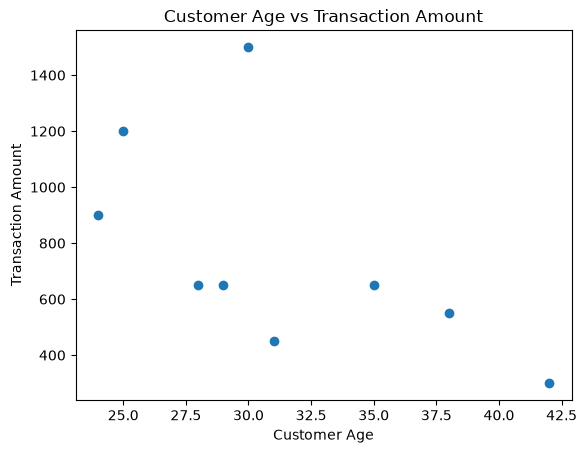

In [14]:
fig, ax = plt.subplots()

ax.scatter(
    cleaned_df["customer_age"],
    cleaned_df["amount"]
)

ax.set_title("Customer Age vs Transaction Amount")
ax.set_xlabel("Customer Age")
ax.set_ylabel("Transaction Amount")

plt.show()

### Finding

The scatter plot compares customer age with transaction amount. The observations do not show an obvious consistent upward or downward pattern in this small sample.

Therefore, the visualization does not provide strong evidence of a clear relationship between customer age and transaction amount. Because the dataset is very small, a larger dataset would be required to investigate this relationship more reliably.

### Choosing the Chart Based on the Question

The three visualizations answer different types of analytical questions:

| Analytical Question | Data Structure | Appropriate Chart |
|---|---|---|
| How are transaction amounts distributed? | One numerical variable | Histogram |
| Which category has the highest total? | Category + numerical aggregate | Bar chart |
| Is age related to transaction amount? | Two numerical variables | Scatter plot |

The chart type is therefore selected based on the question and the structure of the data rather than personal preference.

## 4. Comparing Multiple Visualizations with Subplots

Individual charts answer specific analytical questions, but placing related visualizations in a single figure can make comparison easier.

Matplotlib's `subplots()` function allows multiple Axes to be created within one Figure. We will use a 2×2 layout to display several views of the cleaned sales dataset together.

### Preparing Category-Level Summaries

The subplot figure will include both transaction-level and category-level views. We therefore calculate the average transaction amount for each category for an additional comparison.

In [15]:
mean_amount_by_category = (
    cleaned_df
    .groupby("category")["amount"]
    .mean()
)

mean_amount_by_category

category
clothing        550.0
electronics    1062.5
furniture       475.0
Name: amount, dtype: float64

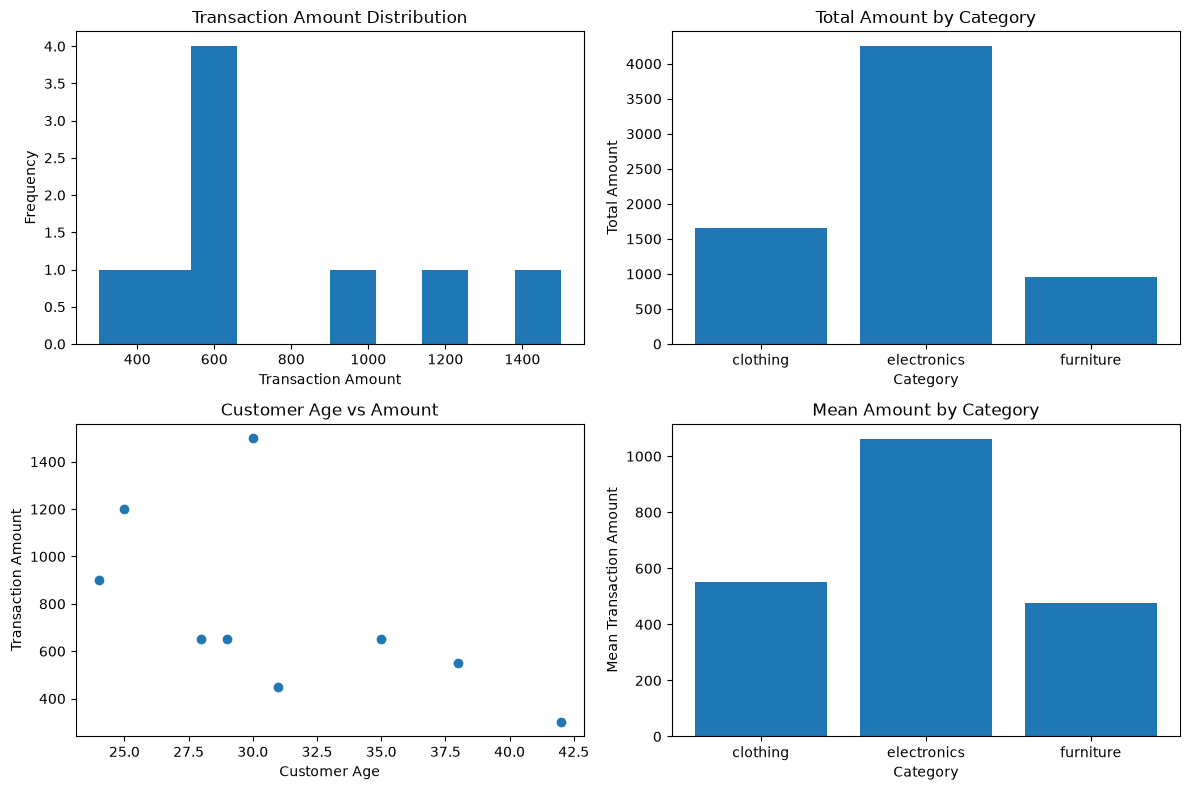

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1 — Distribution
axes[0, 0].hist(cleaned_df["amount"])
axes[0, 0].set_title("Transaction Amount Distribution")
axes[0, 0].set_xlabel("Transaction Amount")
axes[0, 0].set_ylabel("Frequency")

# Plot 2 — Total by Category
axes[0, 1].bar(
    total_amount_by_category.index,
    total_amount_by_category.values
)
axes[0, 1].set_title("Total Amount by Category")
axes[0, 1].set_xlabel("Category")
axes[0, 1].set_ylabel("Total Amount")

# Plot 3 — Age vs Amount
axes[1, 0].scatter(
    cleaned_df["customer_age"],
    cleaned_df["amount"]
)
axes[1, 0].set_title("Customer Age vs Amount")
axes[1, 0].set_xlabel("Customer Age")
axes[1, 0].set_ylabel("Transaction Amount")

# Plot 4 — Mean by Category
axes[1, 1].bar(
    mean_amount_by_category.index,
    mean_amount_by_category.values
)
axes[1, 1].set_title("Mean Amount by Category")
axes[1, 1].set_xlabel("Category")
axes[1, 1].set_ylabel("Mean Transaction Amount")

plt.tight_layout()
plt.show()

In [17]:
print("Axes array shape:", axes.shape)
print("Number of axes:", len(fig.axes))

Axes array shape: (2, 2)
Number of axes: 4


### Why Use Subplots?

The subplot layout allows multiple related views of the dataset to be examined within the same Figure.

The histogram shows the overall distribution of transaction amounts, the total-amount bar chart compares category-level sales, the scatter plot examines the relationship between customer age and transaction amount, and the mean-amount chart compares typical transaction values across categories.

Viewing these plots together makes it easier to compare different aspects of the same dataset without switching between separate figures.

### Interpretation

The combined figure provides several complementary views of the cleaned sales data.

- The histogram shows the distribution of transaction amounts.
- The total-amount bar chart shows which categories contribute the most overall sales.
- The scatter plot shows whether an obvious relationship exists between customer age and transaction amount.
- The mean-amount bar chart compares the typical transaction value across categories.

Viewing these visualizations together provides a broader understanding of the dataset than any single chart would provide.

## 5. Honest vs Misleading Visualization

A visualization can use correct underlying data while still creating a misleading impression through its visual scale.

In this section, we will create an honest category comparison and then deliberately manipulate the y-axis to exaggerate the apparent difference between categories.

The purpose is to understand why axis choices and visual scaling are part of analytical integrity.

In [18]:
total_amount_by_category

category
clothing       1650.0
electronics    4250.0
furniture       950.0
Name: amount, dtype: float64

### Honest Visualization

The honest version of the chart uses a y-axis beginning at zero. This allows the visual height of each bar to represent its magnitude proportionally.

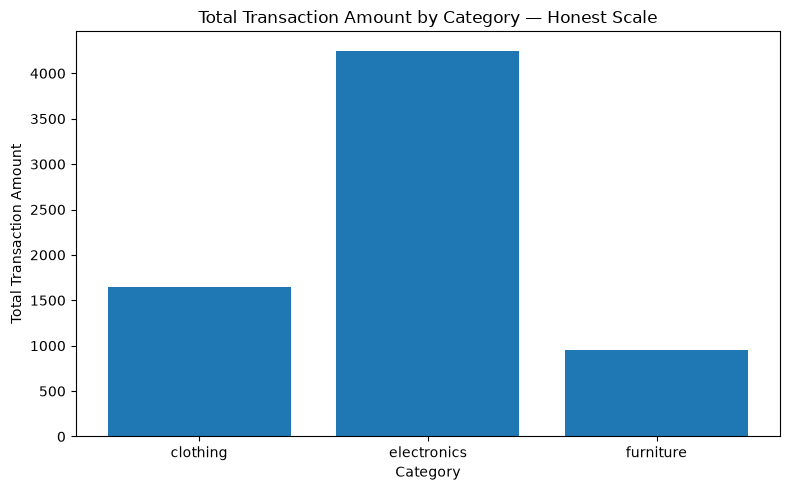

In [19]:
fig_honest, ax_honest = plt.subplots(figsize=(8, 5))

ax_honest.bar(
    total_amount_by_category.index,
    total_amount_by_category.values
)

ax_honest.set_title("Total Transaction Amount by Category — Honest Scale")
ax_honest.set_xlabel("Category")
ax_honest.set_ylabel("Total Transaction Amount")

plt.tight_layout()
plt.show()

### Deliberately Misleading Visualization

We will now create a second version using the same underlying data but truncate the y-axis so that it starts close to the observed values instead of zero.

This does not change the data. However, it can make relatively small differences between categories appear much larger visually.

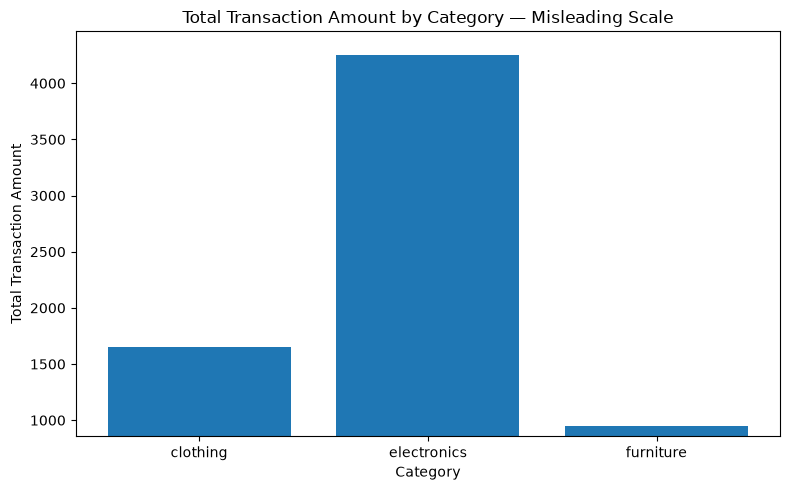

In [20]:
fig_misleading, ax_misleading = plt.subplots(figsize=(8, 5))

ax_misleading.bar(
    total_amount_by_category.index,
    total_amount_by_category.values
)

ax_misleading.set_title("Total Transaction Amount by Category — Misleading Scale")
ax_misleading.set_xlabel("Category")
ax_misleading.set_ylabel("Total Transaction Amount")

minimum_value = total_amount_by_category.min()

ax_misleading.set_ylim(
    minimum_value * 0.9,
    total_amount_by_category.max() * 1.05
)

plt.tight_layout()
plt.show()

### What Changed?

The underlying category totals are identical in both charts. The only major difference is the y-axis range.

The honest chart starts the y-axis at zero, while the misleading chart begins near the minimum observed value. This makes the vertical differences between the bars appear larger than they are relative to the full scale.

### Why the Second Chart Is Misleading

The second chart is misleading because its truncated y-axis visually exaggerates the differences between categories.

The numerical values themselves have not been changed, but the visual scale changes how large the differences appear to the viewer.

For a bar chart representing quantities, beginning the y-axis at zero provides a more proportional visual representation of the magnitude of each category.

In [21]:
print("Honest y-axis limits:", ax_honest.get_ylim())
print("Misleading y-axis limits:", ax_misleading.get_ylim())

Honest y-axis limits: (np.float64(0.0), np.float64(4462.5))
Misleading y-axis limits: (np.float64(855.0), np.float64(4462.5))


### Honest vs Misleading Comparison

Both charts use the same category totals, so the underlying data is identical.

The honest chart provides a proportional comparison because the y-axis starts at zero. The misleading chart truncates the y-axis, making the differences between categories visually more dramatic than their actual numerical differences.

This demonstrates that visualization choices can influence interpretation even when the underlying data is correct.

### EDA Lesson

A visualization is part of the analysis, not merely a decorative output. Axis ranges, scales, labels, and chart types can affect how readers interpret the data.

Therefore, an analyst should choose visual settings that represent the underlying data honestly and avoid unnecessary visual exaggeration.

## 6. Saving a Figure

Visualizations created in a Jupyter notebook may also need to be used outside the notebook in reports, presentations, documentation, or other applications.

Matplotlib provides `fig.savefig()` to save a Figure as an image file. In this section, we will save an analytical chart as a PNG file and verify that the file was created successfully.

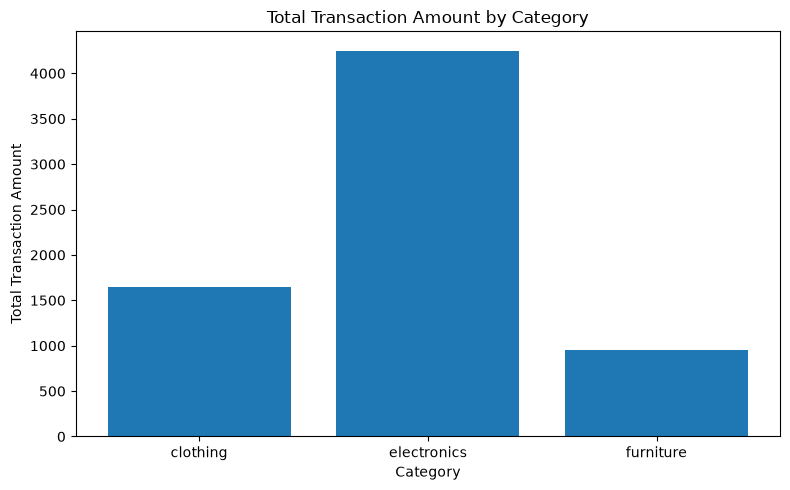

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    total_amount_by_category.index,
    total_amount_by_category.values
)

ax.set_title("Total Transaction Amount by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total Transaction Amount")

plt.tight_layout()
plt.show()

In [23]:
fig.savefig(
    "category_totals.png",
    dpi=150,
    bbox_inches="tight"
)

In [24]:
from pathlib import Path

output_file = Path("category_totals.png")

print("File exists:", output_file.exists())
print("File size:", output_file.stat().st_size, "bytes")

File exists: True
File size: 31435 bytes


### Interpretation

The figure was successfully exported as a PNG file using `fig.savefig()`.

The saved image can be opened independently of the Jupyter notebook, which makes the visualization reusable in reports, presentations, documentation, or other applications.

Using `dpi=150` provides a reasonable resolution, while `bbox_inches="tight"` helps ensure that titles and axis labels are included within the saved image boundaries.

## 8. Overall Findings

The exploratory analysis produced several observations:

1. Transaction amounts vary across the observed dataset, with most values concentrated within the sample's general range.

2. The category-level analysis shows that transaction totals differ between categories, allowing the highest-contributing category to be identified programmatically.

3. The scatter plot does not show a strong obvious relationship between customer age and transaction amount in this small sample.

4. Multiple visualizations provide complementary perspectives and are easier to compare when presented together using subplots.

5. The honest-versus-misleading visualization demonstrates that axis scaling can substantially influence visual interpretation even when the underlying data remains unchanged.

## 9. Limitations

The dataset used in this exercise is intentionally small and simplified for learning purposes. Therefore, the observed patterns should not be generalized to a larger customer population.

The visualizations demonstrate EDA techniques and interpretation principles rather than providing statistically reliable business conclusions.

A larger and more representative dataset would be required for stronger conclusions about customer behavior, category performance, or relationships between variables.

## Conclusion

This notebook demonstrated a complete introductory EDA workflow using Pandas and Matplotlib.

The cleaned sales dataset was examined through multiple visualization types selected according to specific analytical questions. Histograms were used to examine distributions, bar charts compared category-level values, and scatter plots explored relationships between numerical variables.

Matplotlib's Figure and Axes model was used to create both individual and multi-plot visualizations. The analysis also demonstrated the importance of honest visual scaling and showed how saving figures allows visualizations to be reused outside the notebook.

The overall workflow can be summarized as:

Clean → Ask → Visualize → Interpret → Report